In [9]:
import pandas as pd
import matplotlib.pyplot as plt

orders = pd.read_csv("orders.csv")
products = pd.read_csv("products.csv")

In [2]:
df = orders.merge(products, on="product_id", how="left")

grouped = (
    df.groupby(["product_category", "region"])["revenue"]
    .sum()
    .reset_index(name="total_revenue")
)

In [3]:
# % contribution

grouped["pct_contribution"] = (
    grouped["total_revenue"] /
    grouped.groupby("region")["total_revenue"].transform("sum")
) * 100

In [6]:
# Order type

grouped["order_type"] = grouped["total_revenue"].apply(
    lambda x: "High" if x >= 2000 else "Low"
)

grouped = grouped.sort_values(by="total_revenue", ascending=False)

In [7]:
#Sort

pivot_df = grouped.pivot(
    index="region",
    columns="product_category",
    values="pct_contribution"
).fillna(0)

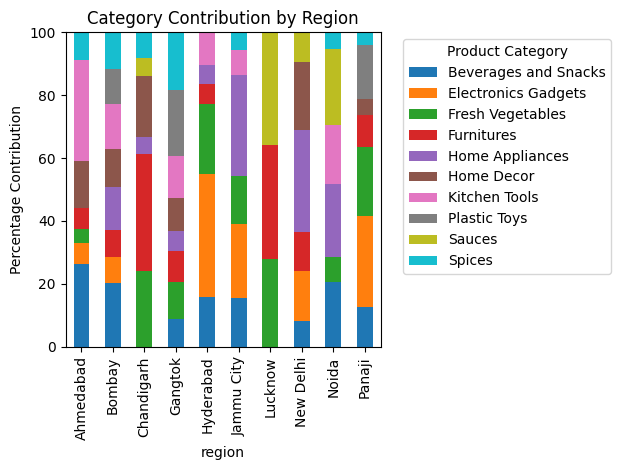

In [10]:
pivot_df.plot(
    kind="bar",
    stacked=True
)

plt.ylabel("Percentage Contribution")
plt.title("Category Contribution by Region")
plt.legend(title="Product Category", bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()